In [6]:
import pandas as pd
import numpy as np
import sys
import os
from tqdm import tqdm
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Import metrics

In [8]:
#metadata for both argumentative and creative writing sessions
metadata_argumentative = pd.read_csv('../data/CoAuthor/add_data/metadata_argumentative.csv')
metadata_creative = pd.read_csv('../data/CoAuthor/add_data/metadata_creative.csv')

metadata_argumentative['type'] = 'argumentative'
metadata_creative['type'] = 'creative'

metadata = pd.concat([metadata_argumentative, metadata_creative], ignore_index=True)

In [2]:
all_metrics = pd.read_csv('../data/all_metrics.csv')

In [10]:
#Filter selected sessions
metadata = metadata.merge(all_metrics['session_id'], on='session_id', how='right')

# Descriptive overview

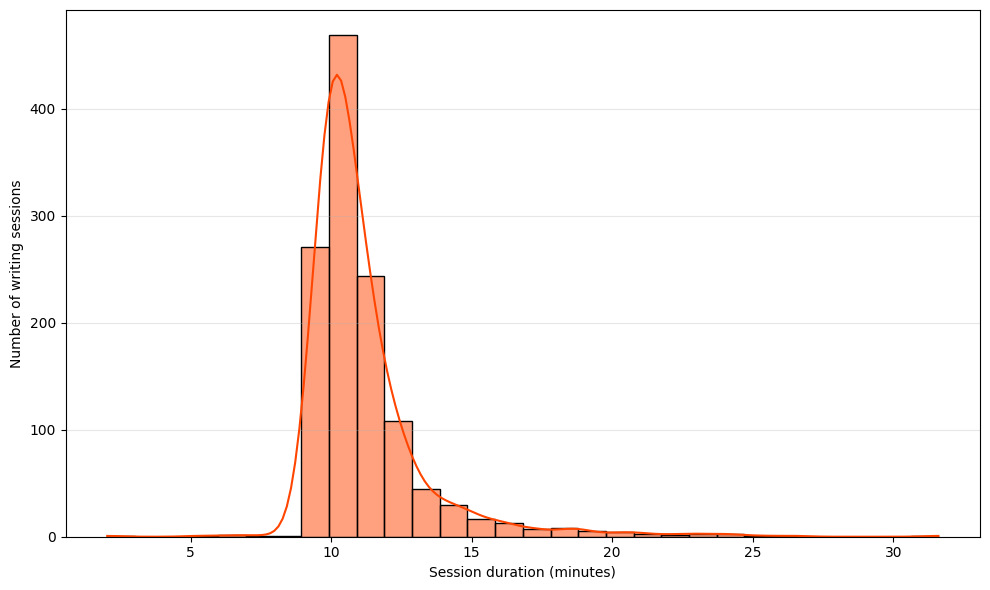

In [11]:
# Distribution of session duration
session_duration = metadata['time']  # each window represents 1 minute

plt.figure(figsize=(10, 6))
sns.histplot(session_duration, bins=30, kde=True, color='orangered')
plt.xlabel('Session duration (minutes)')
plt.ylabel('Number of writing sessions')
plt.title('')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
metadata['time'].describe()

count    1241.000000
mean       11.169766
std         2.238621
min         2.030000
25%         9.960000
50%        10.540000
75%        11.550000
max        31.610000
Name: time, dtype: float64

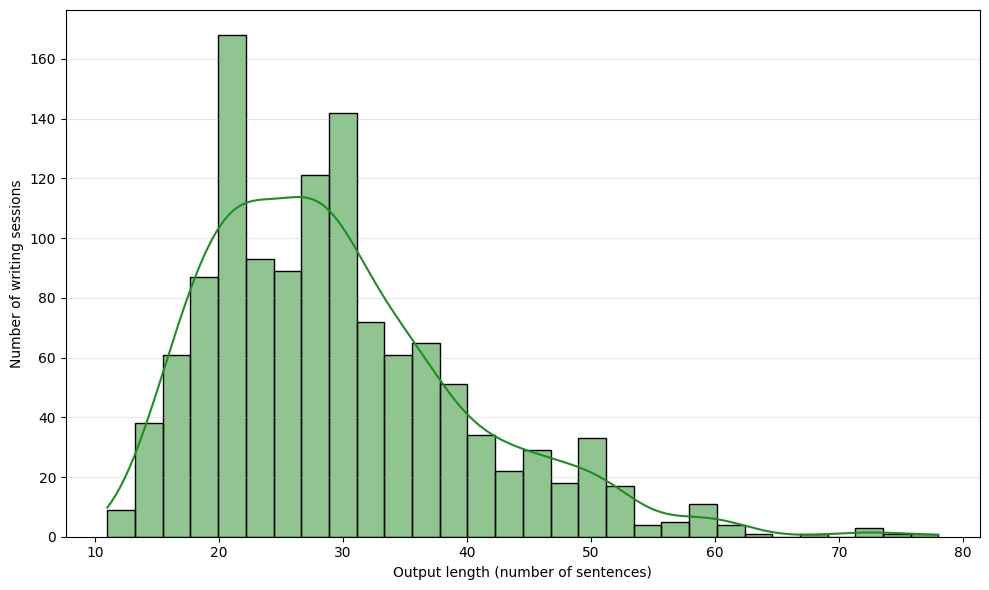

In [13]:
# Distribution of session duration
session_duration = metadata['time']

plt.figure(figsize=(10, 6))
sns.histplot(all_metrics['nb_sentences_total'], bins=30, kde=True, color='forestgreen')
plt.xlabel('Output length (number of sentences)')
plt.ylabel('Number of writing sessions')
plt.title('')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
all_metrics['nb_sentences_total'].describe()

count    1241.000000
mean       29.538276
std        10.510687
min        11.000000
25%        22.000000
50%        28.000000
75%        35.000000
max        78.000000
Name: nb_sentences_total, dtype: float64

In [15]:
session_counts = pd.DataFrame(all_metrics.groupby('worker_id')['session_id'].nunique()).rename(columns={'session_id':'nb_sessions'})

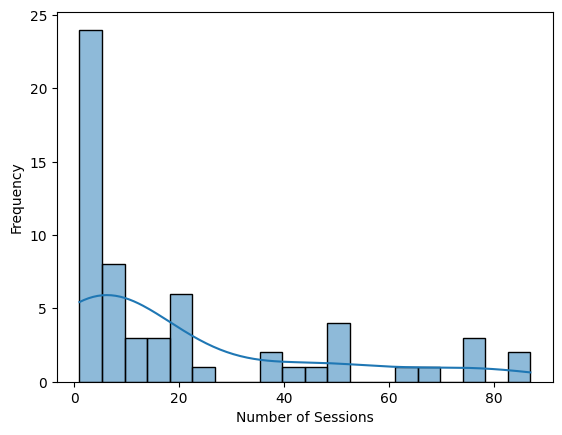

In [16]:
# Plot the distribution of session counts
sns.histplot(session_counts.nb_sessions, bins=20, kde=True)
# plt.title('Distribution of Number of Sessions by Writer')
plt.xlabel('Number of Sessions')
plt.ylabel('Frequency')
plt.show()

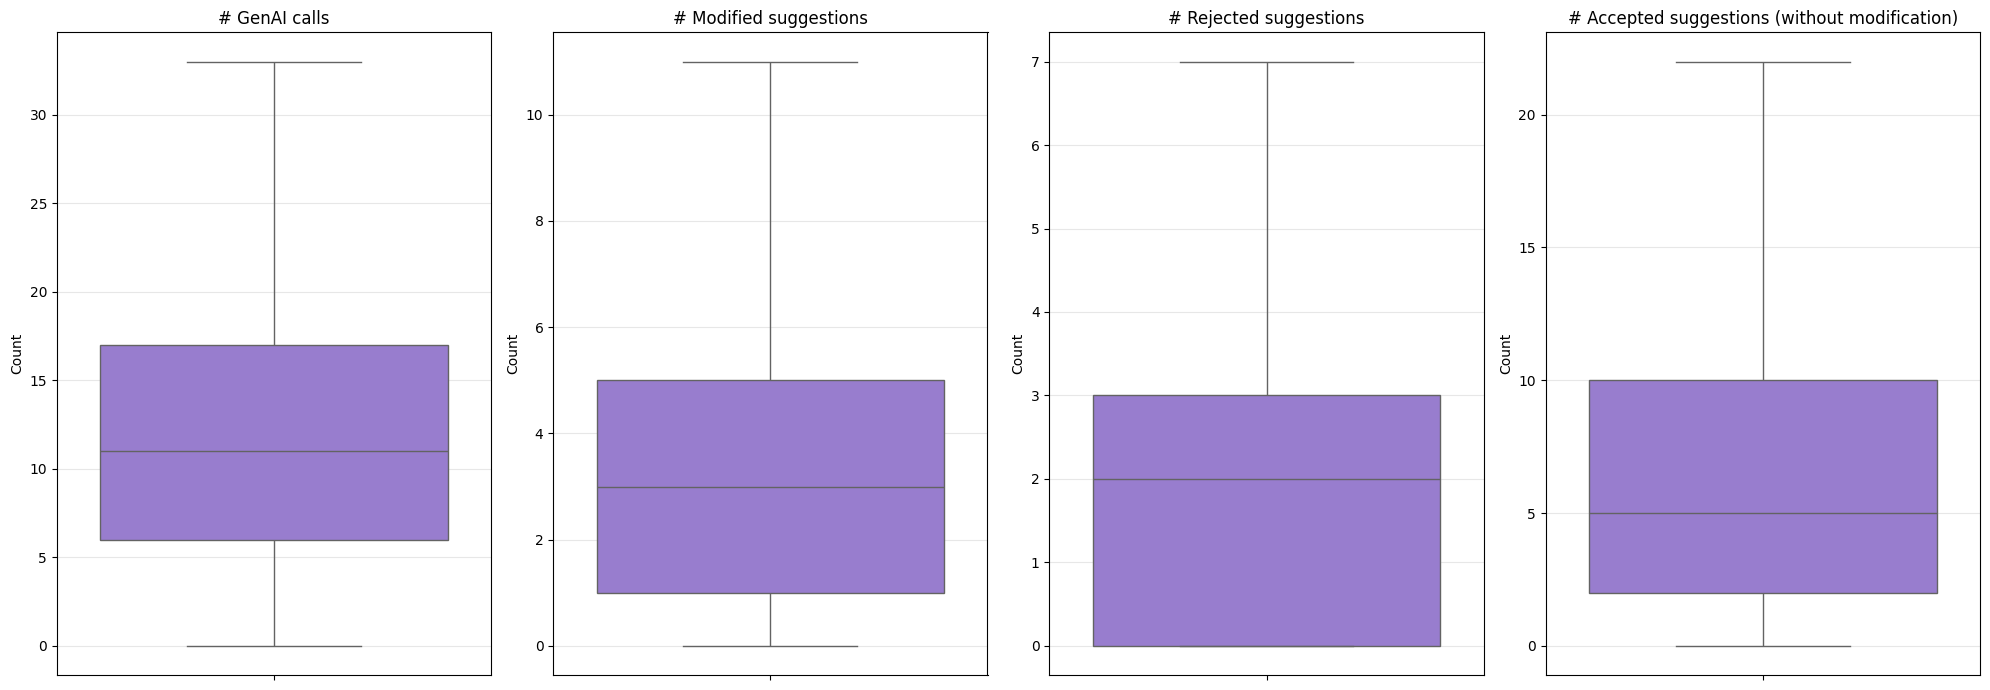

In [7]:
boxplot_features = [
    'nb_gpt_calls',
    'nb_rejected_suggestions',
    'nb_modified_suggestions',
    'nb_accepted_as_it_is_suggestions'
 ]

boxplot_titles = [
    '# GenAI calls',
    '# Modified suggestions',
    '# Rejected suggestions',
    '# Accepted suggestions (without modification)'
 ]

fig, axes = plt.subplots(1, 4, figsize=(20, 7))

for ax, feature, title in zip(axes, boxplot_features, boxplot_titles):
    sns.boxplot(
        y=all_metrics[feature],
        ax=ax,
        color='mediumpurple',
        showfliers=False
    )
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()